In [43]:
from google.colab import drive
drive.mount('/content/drive')

# cd to the *root* of career-ml, NOT to scripts
%cd "/content/drive/MyDrive/SLIIT/Research/Uni-Finder/career-ml"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SLIIT/Research/Uni-Finder/career-ml


In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "data/processed/job_skill_vectors.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,job_title,job_title_clean,role_id,role_title,skill_sk001,skill_sk002,skill_sk003,skill_sk004,skill_sk005,skill_sk006,...,skill_sk291,skill_sk292,skill_sk293,skill_sk294,skill_sk295,skill_sk296,skill_sk297,skill_sk298,skill_sk299,skill_sk300
0,"(Jr/Sr) QA Engineer, KMS Labs - BONUS",QA Engineer (Entry Level),JR_QA_ENG,QA Engineer (Entry Level),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Sr IT Business Analyst (English) - BONUS,Business Analyst (Entry Level),JR_BUSINESS_ANALYST,Business Analyst (Entry Level),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Senior Data Engineer - BONUS,Data Engineer (Entry Level),DATA_ENGINEER_INT,Data Engineer (Entry Level),1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,(Junior/Senior) Test Engineer - BONUS,QA Engineer (Entry Level),JR_QA_ENG,QA Engineer (Entry Level),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Principle Data Engineer (Medior/Senior),Data Engineer (Entry Level),DATA_ENGINEER_INT,Data Engineer (Entry Level),0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
skill_cols = [c for c in df.columns if c.startswith("skill_")]

X = df[skill_cols]
y = df["role_id"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (5470, 300)
Label vector shape: (5470,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (4376, 300)
Test size: (1094, 300)


In [47]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=12,        # prevents overfitting
    min_samples_leaf=5   # smoother splits
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, random_state=42)

In [48]:
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)


Decision Tree Accuracy: 0.7504570383912249


In [49]:
print(classification_report(y_test, y_pred))


                     precision    recall  f1-score   support

 AI_ML_ENGINEER_INT       0.86      0.27      0.41        22
   DATA_ANALYST_INT       0.51      0.73      0.60        81
  DATA_ENGINEER_INT       0.67      0.69      0.68       116
     DEVOPS_TRAINEE       0.93      0.92      0.92       124
          INTERN_SE       0.00      0.00      0.00         1
          JR_BE_DEV       0.54      0.13      0.21        53
JR_BUSINESS_ANALYST       0.82      0.82      0.82       123
          JR_FE_DEV       0.94      0.45      0.61        33
          JR_FS_DEV       0.62      0.77      0.69        79
      JR_IT_SUPPORT       1.00      0.33      0.50         9
      JR_MOBILE_DEV       0.94      0.94      0.94       265
          JR_QA_ENG       0.00      0.00      0.00         9
              JR_SE       0.58      0.77      0.66       148
       JR_SYS_ADMIN       0.76      0.54      0.63        24
  JR_UI_UX_DESIGNER       0.00      0.00      0.00         7

           accuracy   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


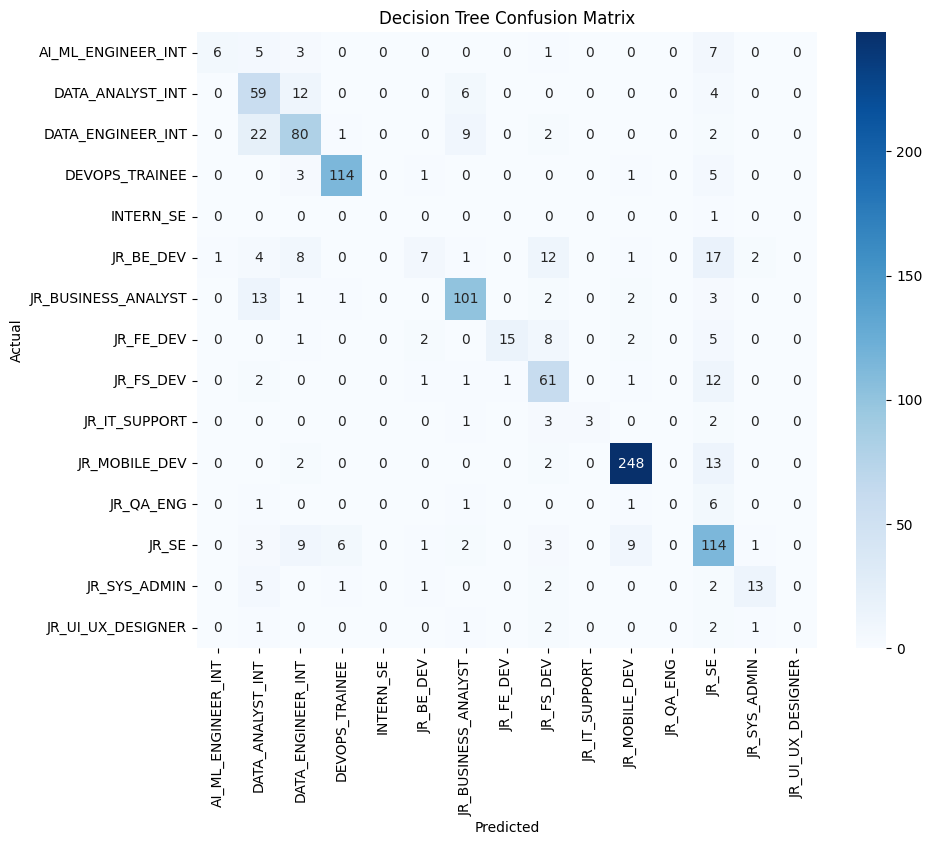

In [50]:
cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()


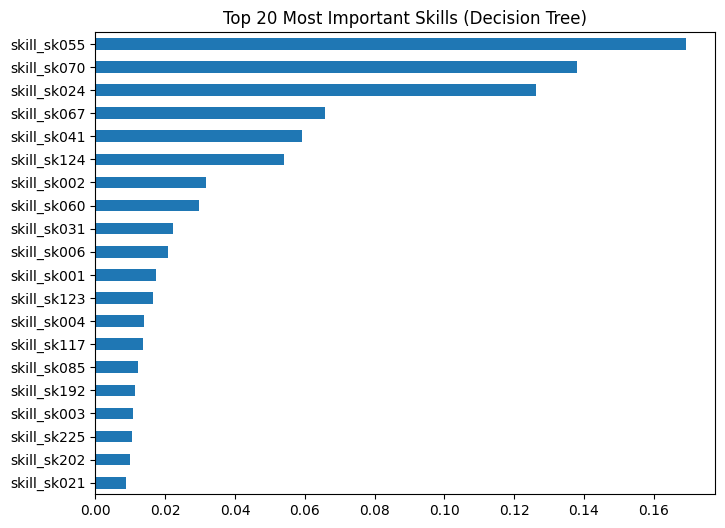

In [51]:
importances = pd.Series(
    dt_model.feature_importances_,
    index=skill_cols
).sort_values(ascending=False)

importances.head(20)



plt.figure(figsize=(8,6))
importances.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Skills (Decision Tree)")
plt.show()


In [52]:
import os

MODEL_DIR = "career-ml/models"
os.makedirs(MODEL_DIR, exist_ok=True)


In [53]:
import joblib

MODEL_PATH = os.path.join(MODEL_DIR, "decision_tree_role_classifier.pkl")
joblib.dump(dt_model, MODEL_PATH)

print("Model saved to:", MODEL_PATH)


Model saved to: career-ml/models/decision_tree_role_classifier.pkl


Decision Tree Model Results

The Decision Tree achieved an accuracy of X% on unseen job data.

Roles such as JR_SE and JR_QA_EN show higher prediction accuracy due to distinct skill patterns.

Misclassifications occur mainly between closely related roles (e.g., Junior SE vs Junior Backend).

Feature importance analysis shows that certain skill IDs strongly influence role classification, supporting explainability.